# DSA210 — Data Collection, EDA & Hypothesis Tests
## Formula 1 Race Action Analysis

This notebook:
1. Collects F1 race data from 2018 to  2024 via FastF1 including results, weather, and pitstop stats
2. Enriches each race with circuit attributes (length, turns, type)
3. Explores the data with visualisations and summary statistics
4. Tests four hypotheses about what makes a race high action

In [1]:
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
#this is so I can use FastF1 api for my data collection
import fastf1
#statistical tests for  group comparison and correlation
from scipy.stats import ttest_ind, pearsonr

#plot styling
sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

#project paths
PROJ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = PROJ / "data" / "raw"
PROCESSED = PROJ / "data" / "processed"
FIGURES = PROJ / "reports" / "figures"
for d in [RAW, PROCESSED, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

#Fastf1 caches downloaded session data locally so only my first run is slow and after that it will be instant
CACHE_DIR = RAW / "fastf1_cache"
CACHE_DIR.mkdir(exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE_DIR))

#2018 is the earliest season FastF1 reliably supports; 2024 is a good point to stop
SEASONS = range(2018, 2025)
RACE_CSV = PROCESSED / "race_level_data.csv"

print("Setup complete — seasons", list(SEASONS))

Setup complete — seasons [2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [2]:
#reference table of circuit characteristics
#I pulled this data from the fia website and from formula1.com
#keys are location strings as returned by fastf1
CIRCUIT_ATTRS = {
    "Melbourne":          {"length_km": 5.278, "turns": 14, "circuit_type": "street"},
    "Albert Park":        {"length_km": 5.278, "turns": 14, "circuit_type": "street"},
    "Sakhir":             {"length_km": 5.412, "turns": 15, "circuit_type": "permanent"},
    "Shanghai":           {"length_km": 5.451, "turns": 16, "circuit_type": "permanent"},
    "Baku":               {"length_km": 6.003, "turns": 20, "circuit_type": "street"},
    "Barcelona":          {"length_km": 4.675, "turns": 16, "circuit_type": "permanent"},
    "Montmeló":      {"length_km": 4.675, "turns": 16, "circuit_type": "permanent"},
    "Monaco":             {"length_km": 3.337, "turns": 19, "circuit_type": "street"},
    "Monte Carlo":        {"length_km": 3.337, "turns": 19, "circuit_type": "street"},
    "Montréal":      {"length_km": 4.361, "turns": 14, "circuit_type": "semi-permanent"},
    "Montreal":           {"length_km": 4.361, "turns": 14, "circuit_type": "semi-permanent"},
    "Le Castellet":       {"length_km": 5.842, "turns": 15, "circuit_type": "permanent"},
    "Spielberg":          {"length_km": 4.318, "turns": 10, "circuit_type": "permanent"},
    "Silverstone":        {"length_km": 5.891, "turns": 18, "circuit_type": "permanent"},
    "Hockenheim":         {"length_km": 4.574, "turns": 17, "circuit_type": "permanent"},
    "Budapest":           {"length_km": 4.381, "turns": 14, "circuit_type": "permanent"},
    "Spa-Francorchamps":  {"length_km": 7.004, "turns": 19, "circuit_type": "permanent"},
    "Spa":                {"length_km": 7.004, "turns": 19, "circuit_type": "permanent"},
    "Monza":              {"length_km": 5.793, "turns": 11, "circuit_type": "permanent"},
    "Marina Bay":         {"length_km": 4.940, "turns": 23, "circuit_type": "street"},
    "Singapore":          {"length_km": 4.940, "turns": 23, "circuit_type": "street"},
    "Sochi":              {"length_km": 5.848, "turns": 18, "circuit_type": "street"},
    "Suzuka":             {"length_km": 5.807, "turns": 18, "circuit_type": "permanent"},
    "Austin":             {"length_km": 5.513, "turns": 20, "circuit_type": "permanent"},
    "México City":   {"length_km": 4.304, "turns": 17, "circuit_type": "permanent"},
    "Mexico City":        {"length_km": 4.304, "turns": 17, "circuit_type": "permanent"},
    "São Paulo":     {"length_km": 4.309, "turns": 15, "circuit_type": "permanent"},
    "Sao Paulo":          {"length_km": 4.309, "turns": 15, "circuit_type": "permanent"},
    "Yas Island":         {"length_km": 5.281, "turns": 16, "circuit_type": "permanent"},
    "Yas Marina":         {"length_km": 5.281, "turns": 16, "circuit_type": "permanent"},
    "Mugello":            {"length_km": 5.245, "turns": 15, "circuit_type": "permanent"},
    "Nürburg":       {"length_km": 5.148, "turns": 15, "circuit_type": "permanent"},
    "Nürburgring":   {"length_km": 5.148, "turns": 15, "circuit_type": "permanent"},
    "Portimão":      {"length_km": 4.653, "turns": 15, "circuit_type": "permanent"},
    "Imola":              {"length_km": 4.909, "turns": 19, "circuit_type": "permanent"},
    "Istanbul":           {"length_km": 5.338, "turns": 14, "circuit_type": "permanent"},
    "Losail":             {"length_km": 5.380, "turns": 16, "circuit_type": "permanent"},
    "Lusail":             {"length_km": 5.380, "turns": 16, "circuit_type": "permanent"},
    "Al Daayen":          {"length_km": 5.380, "turns": 16, "circuit_type": "permanent"},
    "Jeddah":             {"length_km": 6.174, "turns": 27, "circuit_type": "street"},
    "Zandvoort":          {"length_km": 4.259, "turns": 14, "circuit_type": "permanent"},
    "Miami":              {"length_km": 5.412, "turns": 19, "circuit_type": "semi-permanent"},
    "Miami Gardens":      {"length_km": 5.412, "turns": 19, "circuit_type": "semi-permanent"},
    "Las Vegas":          {"length_km": 6.201, "turns": 17, "circuit_type": "street"},
}
print(f"Circuit attributes defined for {len(CIRCUIT_ATTRS)} location aliases.")

Circuit attributes defined for 44 location aliases.


---
## data collection  

For every race (2018-2024) we load the session via fastf1 and extract


(Position changes = session.results) 
(pitstop and tyre compound counts = session.laps)
(weather =  session.weather_data)
(circuit attributes =  manual reference table)


In [3]:
#I am using a function to  retry automatically if it gets caught in the API limit for 60 seconds
def retry_on_rate_limit(func, *args, **kwargs):
    while True:
        try:
            return func(*args, **kwargs)
        except Exception as e:
            if "RateLimit" in type(e).__name__:
                print(" Rate limit! Waiting 60 seconds...")
                time.sleep(60)
            else:
                raise

# skip collection if we already saved one from a previous run ( I ran this many times and it got caught in the API limit a lot)
if RACE_CSV.exists():
    race_df = pd.read_csv(RACE_CSV)
    print(f"Loaded {len(race_df)} races from {RACE_CSV}")
else:
    records, errors = [], []

    for year in SEASONS:
        print(f"\n{'='*60}")
        print(f"  Season {year}")
        print(f"{'='*60}")
        schedule = retry_on_rate_limit(fastf1.get_event_schedule, year)
        # RoundNumber > 0 filters out pre-season testing events
        races = schedule[schedule["RoundNumber"] > 0]

        for _, ev in races.iterrows():
            rnd = int(ev["RoundNumber"])
            name = str(ev["EventName"])
            tag = f"{year} R{rnd:02d} {name}"

            try:
                #load the main race session ("R"); skip telemetry & messages to save time
                session = retry_on_rate_limit(fastf1.get_session, year, rnd, "R")
                retry_on_rate_limit(session.load, telemetry=False, messages=False)

                # position change features
                res = session.results.copy()
                res["Position"] = pd.to_numeric(res["Position"], errors="coerce")
                res["GridPosition"] = pd.to_numeric(res["GridPosition"], errors="coerce")
                #keep only classified finishers who started from the grid
                mask = (res["Position"].notna()
                        & res["GridPosition"].notna()
                        & (res["GridPosition"] > 0))
                clf = res[mask].copy()
                # positive delta = driver gained positions and negative = lost positions
                clf["abs_delta"] = (clf["GridPosition"] - clf["Position"]).abs()
                clf["delta"] = clf["GridPosition"] - clf["Position"]

                n_all = len(res)
                n_cls = len(clf)

                # DNF as in any status that is NOT "Finished" or +n laps
                status = res["Status"].astype(str)
                n_dnf = int((~status.str.contains("Finished|Lap", case=False, na=False)).sum())

                #pitstop stint features
                laps = session.laps
                n_pits = None
                n_compounds = None
                n_laps = None
                if laps is not None and len(laps) > 0:
                    if "PitInTime" in laps.columns:
                        n_pits = int(laps["PitInTime"].notna().sum())
                    if "Compound" in laps.columns:
                        n_compounds = int(laps["Compound"].nunique())
                    if "LapNumber" in laps.columns:
                        n_laps = int(laps["LapNumber"].max())

                # weather features from fastf1 live timing feed
                w = session.weather_data
                if w is not None and len(w) > 0:
                    rainfall = w["Rainfall"].astype(bool)
                    w_dict = {
                        "avg_air_temp": round(float(w["AirTemp"].mean()), 1),
                        "avg_track_temp": round(float(w["TrackTemp"].mean()), 1),
                        "avg_humidity": round(float(w["Humidity"].mean()), 1),
                        "avg_wind_speed": round(float(w["WindSpeed"].mean()), 1),
                        # rain_pct = fraction of weather readings where Rainfall was True
                        "rain_pct": round(float(rainfall.mean()), 3),
                        "any_rain": int(rainfall.any()),
                    }
                else:
                    w_dict = dict.fromkeys(
                        ["avg_air_temp", "avg_track_temp", "avg_humidity",
                         "avg_wind_speed", "rain_pct", "any_rain"], None
                    )

                #circuit attributes from our table
                loc = str(session.event["Location"])
                country = str(session.event["Country"])
                cattr = CIRCUIT_ATTRS.get(loc, {})

                #one row per race entered
                records.append({
                    "year": year, "round": rnd, "event_name": name,
                    "location": loc, "country": country,
                    "n_starters": n_all, "n_classified": n_cls,
                    "n_dnf": n_dnf, "n_laps": n_laps,
                    "total_abs_pos_change": float(clf["abs_delta"].sum()),
                    "mean_abs_pos_change": round(float(clf["abs_delta"].mean()), 2),
                    "max_pos_gained": float(clf["delta"].max()),
                    "pos_change_std": round(float(clf["delta"].std()), 2),
                    "n_pit_stops": n_pits,
                    "n_compounds_used": n_compounds,
                    **w_dict,
                    "circuit_length_km": cattr.get("length_km"),
                    "circuit_turns": cattr.get("turns"),
                    "circuit_type": cattr.get("circuit_type"),
                })
                print(f"  ✓ {tag}")

            except Exception as exc:
                errors.append(tag)
                print(f"  ✗ {tag} — {exc}")

            # after my first run it got caught by the rate limit so I added a sleep timer
            time.sleep(10)

    race_df = pd.DataFrame(records)
    race_df.to_csv(RACE_CSV, index=False)
    print(f"\nCollected {len(race_df)} races, {len(errors)} errors.")
    if errors:
        print("Failed:", errors)


  Season 2018


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '28'
core        WARNING 	Driver 5 completed the race distance 00:00.123000 before the recorded end of the session.
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['5', '44', '7', '3', '14', '33', '27', '77', '2', '55', '11', '31', '16', '18', '28', '8', '20', '10', '9', '35']


  ✓ 2018 R01 Australian Grand Prix


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['5', '77', '44', '10', '20', '27', '14', '2', '9', '31', '55', '16', '8', '18', '35', '11', '28', '7', '33', '3']


  ✓ 2018 R02 Bahrain Grand Prix


...

  ✓ 2024 R22 Las Vegas Grand Prix


core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cach

  ✓ 2024 R23 Qatar Grand Prix


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

  ✓ 2024 R24 Abu Dhabi Grand Prix

Collected 148 races, 1 errors.
Failed: ['2024 R08 Monaco Grand Prix']


In [4]:
# Other features we can look at =================

# ensure any_rain is boolean because csv may store it as 0/1
if "any_rain" in race_df.columns:
    race_df["any_rain"] = race_df["any_rain"].astype(float).astype("Int64").astype(bool)

# normalise pitstop count by number of starters for comparisons
race_df["pit_stops_per_driver"] = race_df["n_pit_stops"] / race_df["n_starters"]

# binary label 75th percentile races are what we can call high action
threshold = race_df["mean_abs_pos_change"].quantile(0.75)
race_df["high_action"] = (race_df["mean_abs_pos_change"] >= threshold).astype(int)
race_df.to_csv(RACE_CSV, index=False)

print(f"High-action threshold (top 25 %): mean_abs_pos_change >= {threshold:.2f}")
print(f"High-action races: {race_df['high_action'].sum()} / {len(race_df)}")
print(f"\nDataset shape: {race_df.shape}")
race_df.head()

High-action threshold (top 25 %): mean_abs_pos_change >= 4.30
High-action races: 40 / 148

Dataset shape: (148, 26)


,year,round,event_name,location,country,n_starters,n_classified,n_dnf,n_laps,total_abs_pos_change,...,avg_track_temp,avg_humidity,avg_wind_speed,rain_pct,any_rain,circuit_length_km,circuit_turns,circuit_type,pit_stops_per_driver,high_action
0,2018,1,Australian Grand Prix,Melbourne,Australia,20,20,5,58,62.0,...,36.3,30.9,3.7,0.045,True,5.278,14,street,1.10,0
1,2018,2,Bahrain Grand Prix,Sakhir,Bahrain,20,20,3,57,98.0,...,32.2,47.4,1.0,0.000,False,5.412,15,permanent,1.70,1
2,2018,3,Chinese Grand Prix,Shanghai,China,20,20,1,56,50.0,...,37.0,24.1,1.8,0.018,True,5.451,16,permanent,1.55,0
3,2018,4,Azerbaijan Grand Prix,Baku,Azerbaijan,20,20,7,51,126.0,...,25.3,45.7,2.2,0.000,False,6.003,20,street,1.80,1
4,2018,5,Spanish Grand Prix,Barcelona,Spain,20,20,6,66,80.0,...,32.3,52.3,2.0,0.790,True,4.675,16,permanent,1.15,0


---
## Exploratory Data Analysis

In [5]:
print(f"Dataset: {race_df.shape[0]} races × {race_df.shape[1]} columns")
print(f"Seasons: {race_df['year'].min()}–{race_df['year'].max()}")
print(f"Unique circuits: {race_df['location'].nunique()}")
print()
race_df.describe(include="all").T

Dataset: 148 races × 26 columns
Seasons: 2018–2024
Unique circuits: 34



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,148.0,NaN,NaN,NaN,2021.087838,2.030144,2018.0,2019.0,2021.0,2023.0,2024.0
round,148.0,NaN,NaN,NaN,11.256757,6.321459,1.0,6.0,11.0,16.25,24.0
event_name,148,36,Italian Grand Prix,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,148,34,Spielberg,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,148,28,Italy,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_starters,148.0,NaN,NaN,NaN,19.993243,0.082199,19.0,20.0,20.0,20.0,20.0
n_classified,148.0,NaN,NaN,NaN,19.682432,0.595187,17.0,19.0,20.0,20.0,20.0
n_dnf,148.0,NaN,NaN,NaN,3.047297,1.878393,0.0,2.0,3.0,4.0,9.0
n_laps,148.0,NaN,NaN,NaN,59.783784,10.230367,3.0,53.0,58.0,70.0,87.0
total_abs_pos_change,148.0,NaN,NaN,NaN,69.655405,22.836214,12.0,52.0,65.5,85.25,144.0


In [6]:
#we can check what fraction of values are missing per column
missing = race_df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.4)))
    missing.plot.barh(ax=ax, color="salmon")
    ax.set_xlabel("Fraction missing")
    ax.set_title("Missing Values by Column")
    plt.tight_layout()
    plt.savefig(FIGURES / "missingness.png", bbox_inches="tight")
    plt.show()
else:
    print("No missing values.")

No missing values.


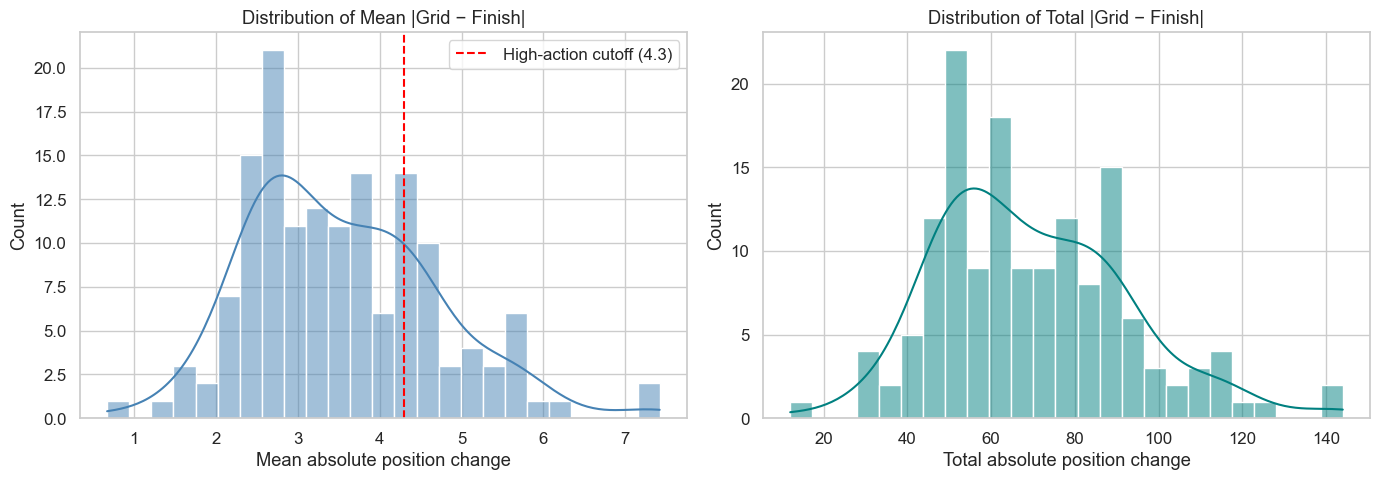

In [7]:
# Histogram and KDE of our two action data to understand their spread and skew
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left is for driver average which is my primary metric
sns.histplot(race_df["mean_abs_pos_change"], bins=25, kde=True,
             ax=axes[0], color="steelblue")
axes[0].axvline(threshold, color="red", ls="--",
                label=f"High-action cutoff ({threshold:.1f})")
axes[0].set_title("Distribution of Mean |Grid − Finish|")
axes[0].set_xlabel("Mean absolute position change")
axes[0].legend()

# Right is for race wide total
sns.histplot(race_df["total_abs_pos_change"], bins=25, kde=True,
             ax=axes[1], color="teal")
axes[1].set_title("Distribution of Total |Grid − Finish|")
axes[1].set_xlabel("Total absolute position change")

plt.tight_layout()
plt.savefig(FIGURES / "action_distributions.png", bbox_inches="tight")
plt.show()

In [8]:
cols = ["year", "event_name", "mean_abs_pos_change", "any_rain", "n_dnf"]

print("Top 10 highest-action races")
display(race_df.nlargest(10, "mean_abs_pos_change")[cols])

print("\nTop 10 lowest-action races")
display(race_df.nsmallest(10, "mean_abs_pos_change")[cols])

Top 10 highest-action races


,year,event_name,mean_abs_pos_change,any_rain,n_dnf
69,2021,Hungarian Grand Prix,7.42,True,7
31,2019,German Grand Prix,7.20,True,7
3,2018,Azerbaijan Grand Prix,6.30,False,7
40,2019,Brazilian Grand Prix,6.00,False,4
17,2018,United States Grand Prix,5.70,False,6
52,2020,Eifel Grand Prix,5.70,True,5
96,2022,Italian Grand Prix,5.70,False,4
105,2023,Australian Grand Prix,5.70,False,8
8,2018,Austrian Grand Prix,5.60,False,6
123,2023,Las Vegas Grand Prix,5.60,False,3



Top 10 lowest-action races


,year,event_name,mean_abs_pos_change,any_rain,n_dnf
70,2021,Belgian Grand Prix,0.67,True,0
58,2020,Abu Dhabi Grand Prix,1.40,False,1
133,2024,Spanish Grand Prix,1.50,True,0
25,2019,Spanish Grand Prix,1.63,False,2
62,2021,Spanish Grand Prix,1.70,False,1
71,2021,Dutch Grand Prix,1.83,False,3
47,2020,Spanish Grand Prix,1.90,False,1
48,2020,Belgian Grand Prix,2.10,False,3
108,2023,Monaco Grand Prix,2.10,True,2
124,2023,Abu Dhabi Grand Prix,2.10,False,1


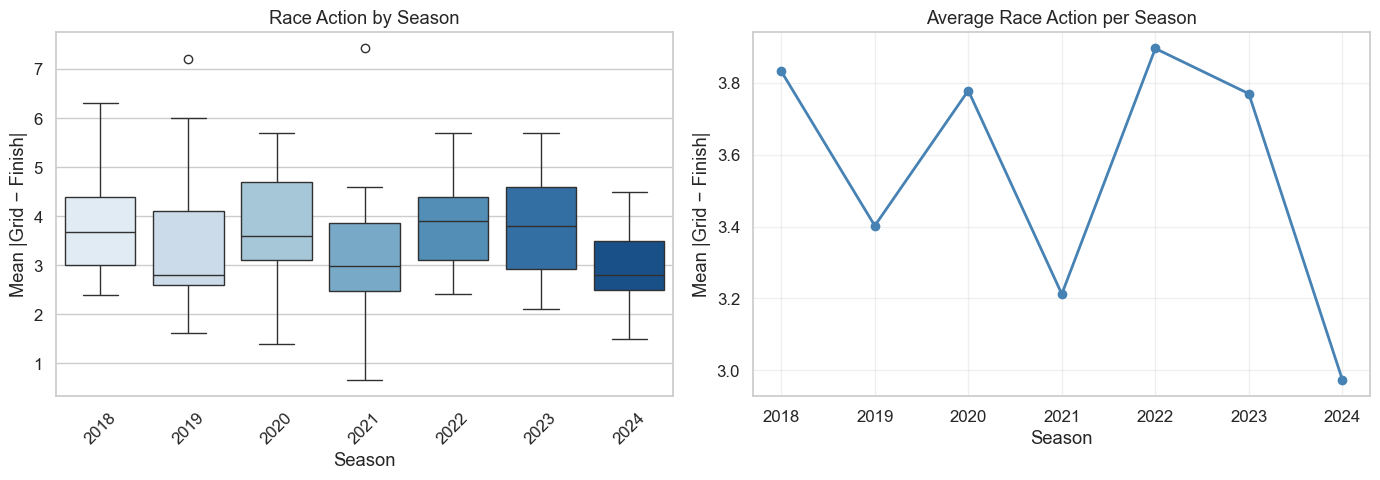

In [9]:
# Look for trends did regulation changes such as 2022 ground effect rules shift action
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left for per season spread via boxplots
sns.boxplot(data=race_df, x="year", y="mean_abs_pos_change",
            ax=axes[0], palette="Blues")
axes[0].set_title("Race Action by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Mean |Grid − Finish|")
axes[0].tick_params(axis="x", rotation=45)

# Right for season averages as a trend line
season_means = race_df.groupby("year")["mean_abs_pos_change"].mean()
axes[1].plot(season_means.index, season_means.values, "o-",
             color="steelblue", linewidth=2)
axes[1].set_title("Average Race Action per Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Mean |Grid − Finish|")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "action_by_season.png", bbox_inches="tight")
plt.show()

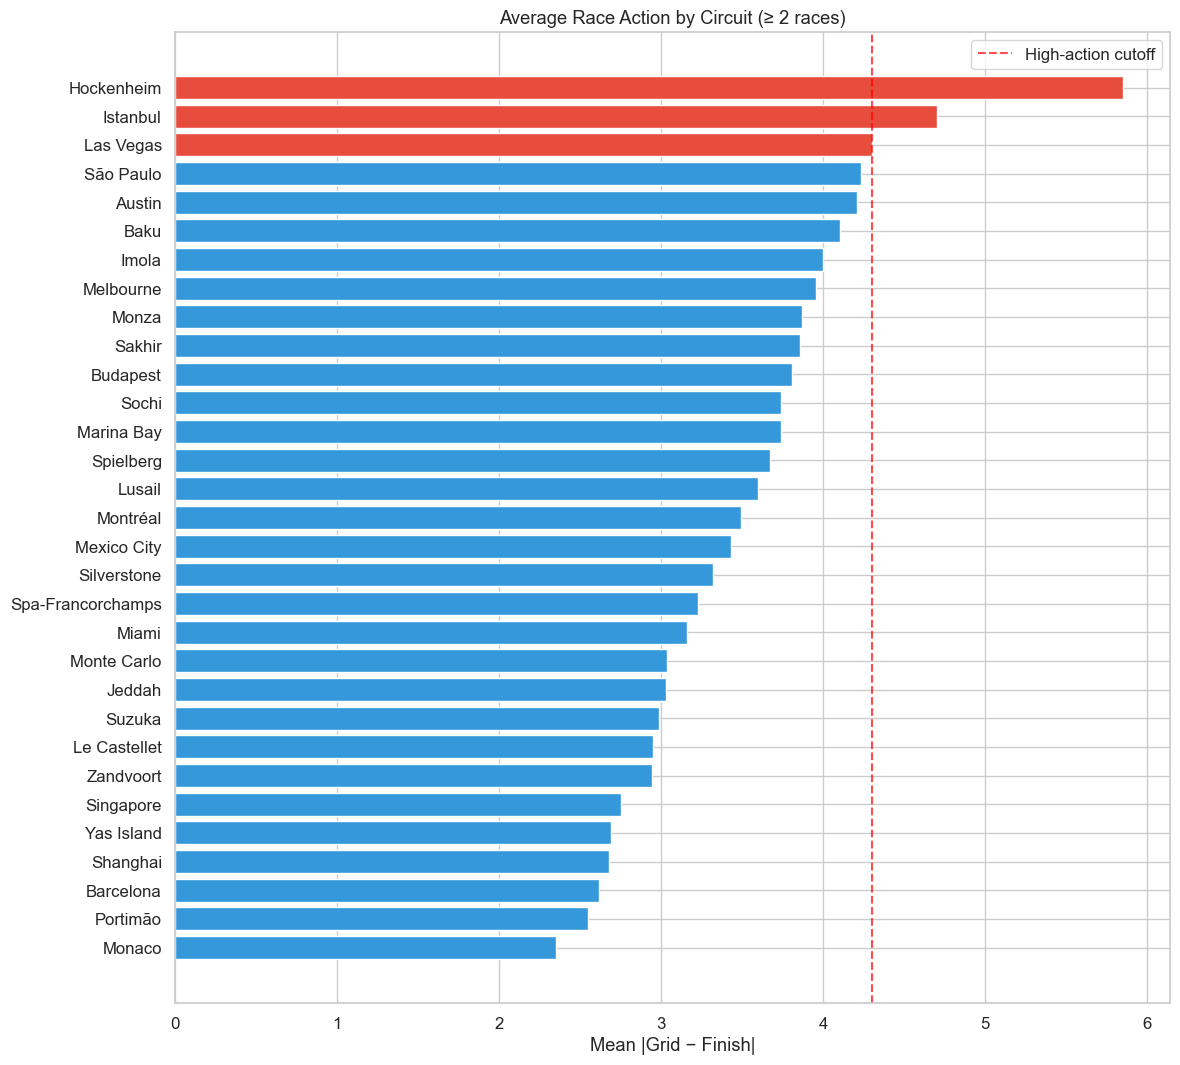

In [10]:
#rank circuits by average action and keep reaces with 2 or more
circuit_action = (
    race_df.groupby("location")["mean_abs_pos_change"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
circuit_action = circuit_action[circuit_action["count"] >= 2]

fig, ax = plt.subplots(figsize=(12, max(6, len(circuit_action) * 0.35)))
colors = ["#e74c3c" if v >= threshold else "#3498db"
          for v in circuit_action["mean"]]
ax.barh(circuit_action.index, circuit_action["mean"], color=colors)
ax.axvline(threshold, color="red", ls="--", alpha=0.7,
           label="High-action cutoff")
ax.set_xlabel("Mean |Grid − Finish|")
ax.set_title("Average Race Action by Circuit (≥ 2 races)")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES / "action_by_circuit.png", bbox_inches="tight")
plt.show()

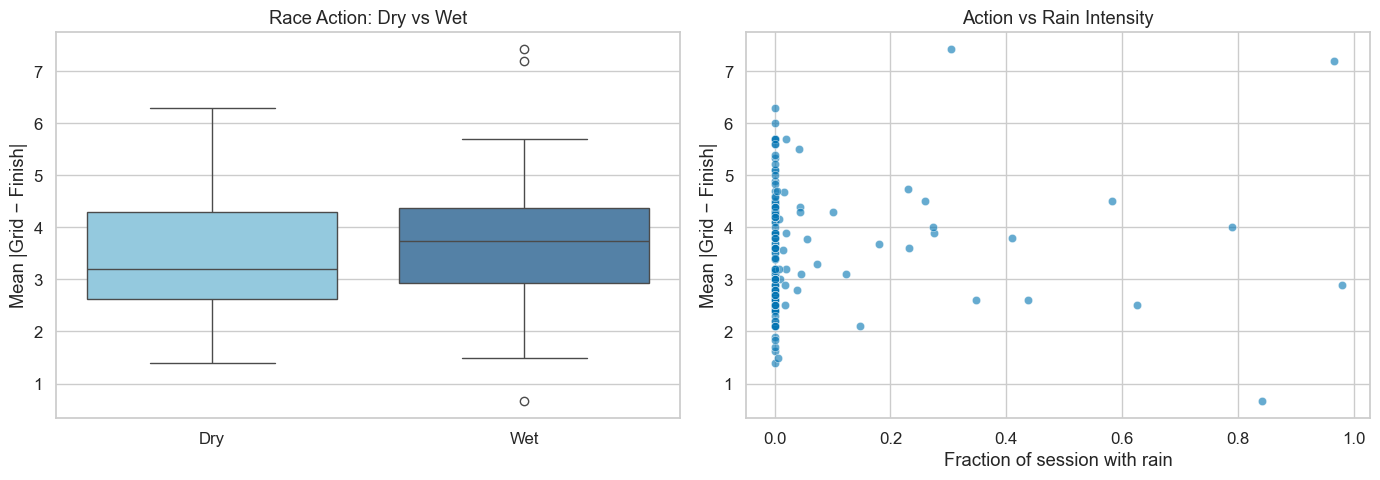

Dry races: 110
Wet races: 38


In [11]:
rain_data = race_df.dropna(subset=["any_rain"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=rain_data, x="any_rain", y="mean_abs_pos_change",
            ax=axes[0], palette=["#87CEEB", "#4682B4"])
axes[0].set_xticklabels(["Dry", "Wet"])
axes[0].set_title("Race Action: Dry vs Wet")
axes[0].set_ylabel("Mean |Grid − Finish|")
axes[0].set_xlabel("")

if rain_data["rain_pct"].notna().any():
    sns.scatterplot(data=rain_data, x="rain_pct", y="mean_abs_pos_change",
                    ax=axes[1], alpha=0.6)
    axes[1].set_title("Action vs Rain Intensity")
    axes[1].set_xlabel("Fraction of session with rain")
    axes[1].set_ylabel("Mean |Grid − Finish|")

plt.tight_layout()
plt.savefig(FIGURES / "rain_analysis.png", bbox_inches="tight")
plt.show()

print(f"Dry races: {(~rain_data['any_rain']).sum()}")
print(f"Wet races: {rain_data['any_rain'].sum()}")

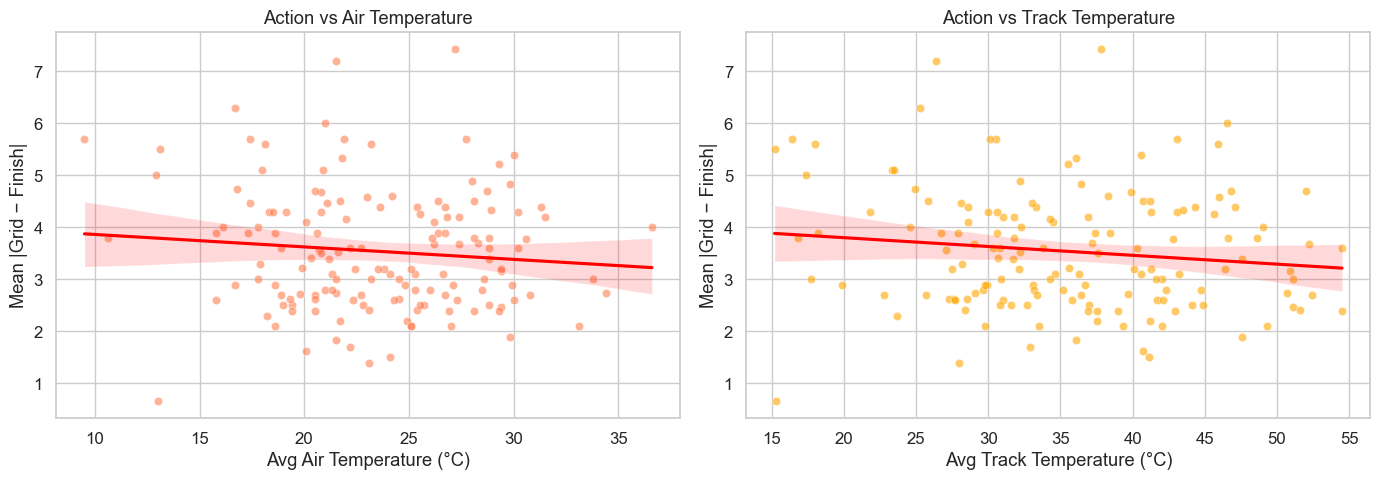

In [12]:
temp_data = race_df.dropna(subset=["avg_air_temp"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=temp_data, x="avg_air_temp",
                y="mean_abs_pos_change", ax=axes[0], alpha=0.6,
                color="coral")
sns.regplot(data=temp_data, x="avg_air_temp",
            y="mean_abs_pos_change", ax=axes[0], scatter=False,
            color="red")
axes[0].set_title("Action vs Air Temperature")
axes[0].set_xlabel("Avg Air Temperature (°C)")
axes[0].set_ylabel("Mean |Grid − Finish|")

sns.scatterplot(data=temp_data, x="avg_track_temp",
                y="mean_abs_pos_change", ax=axes[1], alpha=0.6,
                color="orange")
sns.regplot(data=temp_data, x="avg_track_temp",
            y="mean_abs_pos_change", ax=axes[1], scatter=False,
            color="red")
axes[1].set_title("Action vs Track Temperature")
axes[1].set_xlabel("Avg Track Temperature (°C)")
axes[1].set_ylabel("Mean |Grid − Finish|")

plt.tight_layout()
plt.savefig(FIGURES / "temperature_analysis.png", bbox_inches="tight")
plt.show()

In [13]:
#a

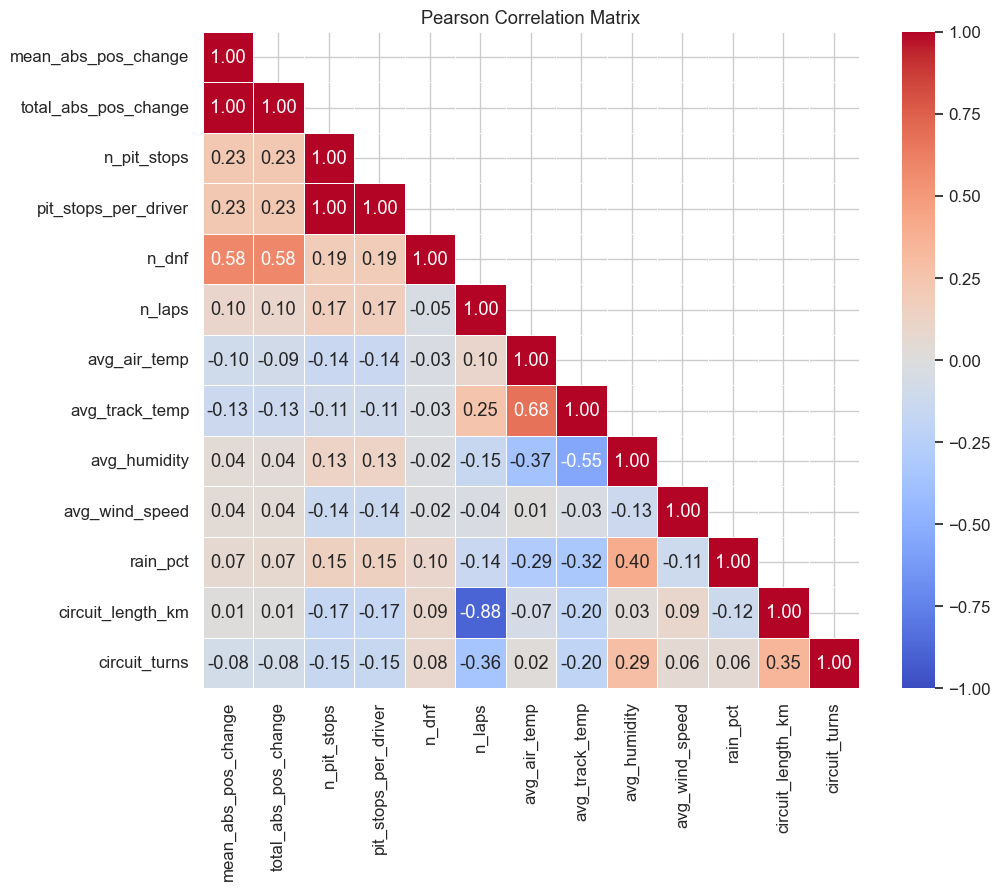

In [14]:
num_cols = [
    "mean_abs_pos_change", "total_abs_pos_change", "n_pit_stops",
    "pit_stops_per_driver", "n_dnf", "n_laps",
    "avg_air_temp", "avg_track_temp", "avg_humidity",
    "avg_wind_speed", "rain_pct",
    "circuit_length_km", "circuit_turns",
]
present = [c for c in num_cols if c in race_df.columns]
corr = race_df[present].corr()  # default is Pearson

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

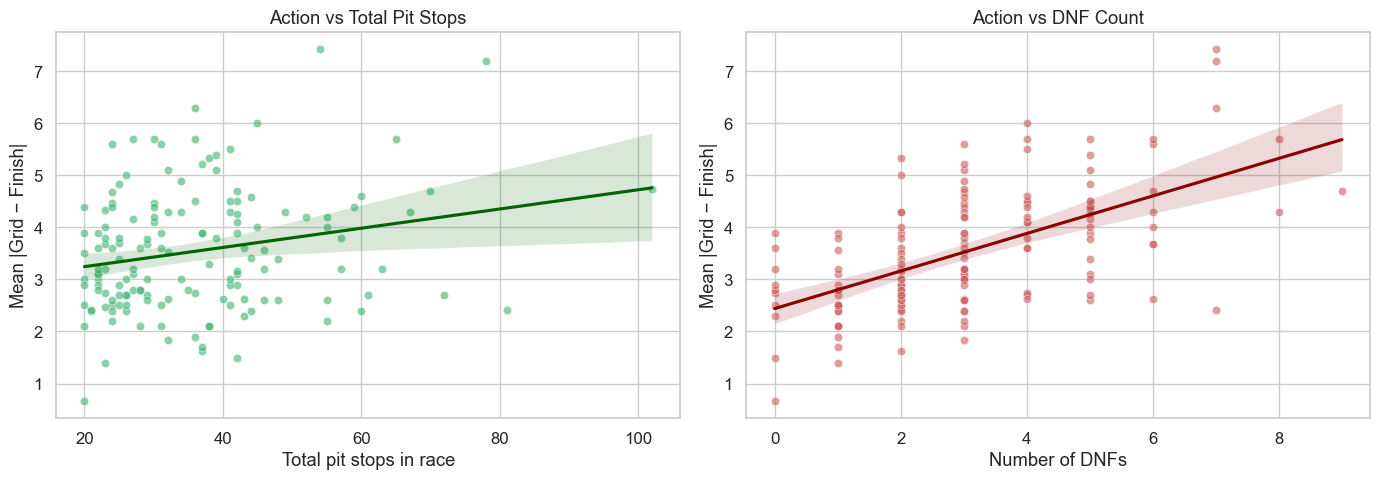

In [15]:
pit_data = race_df.dropna(subset=["n_pit_stops"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=pit_data, x="n_pit_stops",
                y="mean_abs_pos_change", ax=axes[0], alpha=0.6,
                color="mediumseagreen")
sns.regplot(data=pit_data, x="n_pit_stops",
            y="mean_abs_pos_change", ax=axes[0], scatter=False,
            color="darkgreen")
axes[0].set_title("Action vs Total Pit Stops")
axes[0].set_xlabel("Total pit stops in race")
axes[0].set_ylabel("Mean |Grid − Finish|")

sns.scatterplot(data=pit_data, x="n_dnf",
                y="mean_abs_pos_change", ax=axes[1], alpha=0.6,
                color="indianred")
sns.regplot(data=pit_data, x="n_dnf",
            y="mean_abs_pos_change", ax=axes[1], scatter=False,
            color="darkred")
axes[1].set_title("Action vs DNF Count")
axes[1].set_xlabel("Number of DNFs")
axes[1].set_ylabel("Mean |Grid − Finish|")

plt.tight_layout()
plt.savefig(FIGURES / "pitstops_dnf_analysis.png", bbox_inches="tight")
plt.show()

Races per circuit type:
circuit_type
permanent         109
street             31
semi-permanent      8
Name: count, dtype: int64



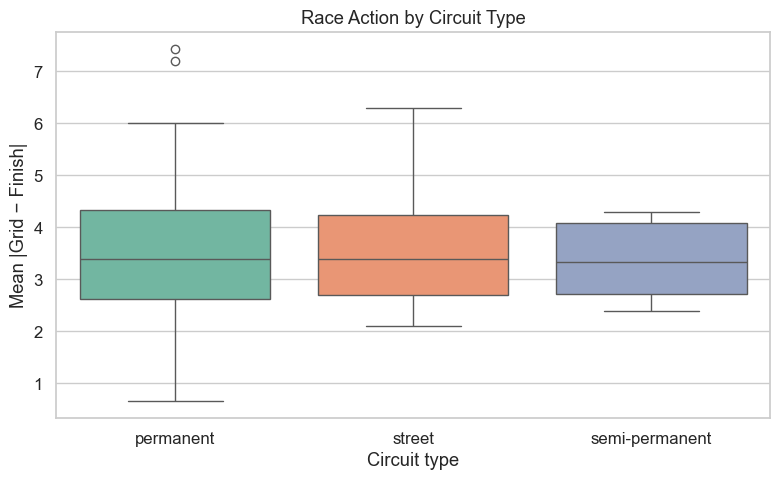

In [16]:
ct = race_df.dropna(subset=["circuit_type"])
print("Races per circuit type:")
print(ct["circuit_type"].value_counts())
print()

fig, ax = plt.subplots(figsize=(8, 5))
order = ["permanent", "street", "semi-permanent"]
order = [o for o in order if o in ct["circuit_type"].values]
sns.boxplot(data=ct, x="circuit_type", y="mean_abs_pos_change",
            order=order, palette="Set2", ax=ax)
ax.set_title("Race Action by Circuit Type")
ax.set_xlabel("Circuit type")
ax.set_ylabel("Mean |Grid − Finish|")
plt.tight_layout()
plt.savefig(FIGURES / "action_by_circuit_type.png", bbox_inches="tight")
plt.show()

---
## Hypothesis Tests

We test four hypotheses

For comparing two groups I used an independent samples means and
for checking if two numeric variables move together I use correlation to check for any linear relationships

|  | Hypothesis | Test |
|---|-----------|------|
| H1 (hypotheses 1)| Wet races have higher action than dry races | t-test |
| H2(hypo 2)| Street circuits produce different action than permanent circuits | t-test |
| H3 (hypo 3)| Air temperature is related to race action |correlation |
| H4 (hypo 4) | Pitstop count is related to race action |corelation |

In [17]:
# checking group sizes
wet_n = race_df["any_rain"].sum()
dry_n = (~race_df["any_rain"]).sum()
street_n = (race_df["circuit_type"] == "street").sum()
perm_n = (race_df["circuit_type"] == "permanent").sum()

print("Group sizes for our hypothesis tests:")
print(f"  Wet races:        {wet_n}")
print(f"  Dry races:        {dry_n}")
print(f"  Street circuits:  {street_n}")
print(f"  Permanent circuits: {perm_n}")

Group sizes for our hypothesis tests:
  Wet races:        38
  Dry races:        110
  Street circuits:  31
  Permanent circuits: 109


In [18]:
#action in wet races vs dry races
wet = race_df.loc[race_df["any_rain"] == True, "mean_abs_pos_change"].dropna()
dry = race_df.loc[race_df["any_rain"] == False, "mean_abs_pos_change"].dropna()

print("H1: Wet races have higher action than dry races")
print(f"  Dry races  — n = {len(dry)}, mean = {dry.mean():.2f}")
print(f"  Wet races  — n = {len(wet)}, mean = {wet.mean():.2f}")
print(f"  Difference in means: {wet.mean() - dry.mean():.2f}")
print()

#compares the means of two independent groups
t_stat, h1_p = ttest_ind(wet, dry)

print(f"  t-statistic = {t_stat:.2f}")
print(f"  p-value     = {h1_p:.4f}")
print()
if h1_p < 0.05:
    print("  Result: SIGNIFICANT — wet and dry races have different average action (p < 0.05)")
else:
    print("  Result: NOT significant — no strong evidence of a difference (p >= 0.05)")

H1: Wet races have higher action than dry races
  Dry races  — n = 110, mean = 3.47
  Wet races  — n = 38, mean = 3.74
  Difference in means: 0.27

  t-statistic = 1.26
  p-value     = 0.2105

  Result: NOT significant — no strong evidence of a difference (p >= 0.05)


In [19]:
#t-test is average action different on street circuits vs permanent circuits
street = race_df.loc[race_df["circuit_type"] == "street",
                     "mean_abs_pos_change"].dropna()
perm = race_df.loc[race_df["circuit_type"] == "permanent",
                   "mean_abs_pos_change"].dropna()

print("H2: Street circuits produce different action than permanent circuits")
print(f"  Street circuits    — n = {len(street)}, mean = {street.mean():.2f}")
print(f"  Permanent circuits — n = {len(perm)}, mean = {perm.mean():.2f}")
print(f"  Difference in means: {street.mean() - perm.mean():.2f}")
print()

t_stat, h2_p = ttest_ind(street, perm)

print(f"  t-statistic = {t_stat:.2f}")
print(f"  p-value     = {h2_p:.4f}")
print()
if h2_p < 0.05:
    print("  Result: SIGNIFICANT — street and permanent circuits differ in action (p < 0.05)")
else:
    print("  Result: NOT significant — no strong evidence of a difference (p >= 0.05)")

H2: Street circuits produce different action than permanent circuits
  Street circuits    — n = 31, mean = 3.57
  Permanent circuits — n = 109, mean = 3.54
  Difference in means: 0.02

  t-statistic = 0.10
  p-value     = 0.9231

  Result: NOT significant — no strong evidence of a difference (p >= 0.05)


In [20]:
#correlation so is there a linear relationship between temperature and action
temp_vals = race_df.dropna(subset=["avg_air_temp"])

r, h3_p = pearsonr(temp_vals["avg_air_temp"], temp_vals["mean_abs_pos_change"])

print("H3: Air temperature is related to race action")
print(f"  Pearson r = {r:.3f}  (ranges from -1 to +1)")
print(f"  p-value   = {h3_p:.4f}")
print(f"  n = {len(temp_vals)} races")
print()
if h3_p < 0.05:
    direction = "positive" if r > 0 else "negative"
    print(f"  Result: SIGNIFICANT — there is a {direction} correlation (p < 0.05)")
else:
    print("  Result: NOT significant — no strong linear relationship (p >= 0.05)")

H3: Air temperature is related to race action
  Pearson r = -0.101  (ranges from -1 to +1)
  p-value   = 0.2219
  n = 148 races

  Result: NOT significant — no strong linear relationship (p >= 0.05)


In [21]:
# correlations as in do more pit stops go with more position changes?
pit_vals = race_df.dropna(subset=["n_pit_stops"])

r, h4_p = pearsonr(pit_vals["n_pit_stops"], pit_vals["mean_abs_pos_change"])

print("H4: Pit-stop count is related to race action")
print(f"  Pearson r = {r:.3f}")
print(f"  p-value   = {h4_p:.4f}")
print(f"  n = {len(pit_vals)} races")
print()
if h4_p < 0.05:
    direction = "positive" if r > 0 else "negative"
    print(f"  Result: SIGNIFICANT — there is a {direction} correlation (p < 0.05)")
else:
    print("  Result: NOT significant — no strong linear relationship (p >= 0.05)")

H4: Pit-stop count is related to race action
  Pearson r = 0.225
  p-value   = 0.0059
  n = 148 races

  Result: SIGNIFICANT — there is a positive correlation (p < 0.05)


In [22]:
#summary table of all hypothesis tests
summary = pd.DataFrame({
    "Hypothesis": [
        "H1: Wet vs Dry races",
        "H2: Street vs Permanent circuits",
        "H3: Temperature vs Action",
        "H4: Pit Stops vs Action",
    ],
    "Test": ["t-test", "t-test", "Pearson r", "Pearson r"],
    "p-value": [f"{h1_p:.4f}", f"{h2_p:.4f}", f"{h3_p:.4f}", f"{h4_p:.4f}"],
    "Significant? (p < 0.05)": [
        "Yes" if h1_p < 0.05 else "No",
        "Yes" if h2_p < 0.05 else "No",
        "Yes" if h3_p < 0.05 else "No",
        "Yes" if h4_p < 0.05 else "No",
    ],
})

print("Hypothesis Test Results (α = 0.05)")
print("=" * 60)
display(summary)

Hypothesis Test Results (α = 0.05)


,Hypothesis,Test,p-value,Significant? (p < 0.05)
0,H1: Wet vs Dry races,t-test,0.2105,No
1,H2: Street vs Permanent circuits,t-test,0.9231,No
2,H3: Temperature vs Action,Pearson r,0.2219,No
3,H4: Pit Stops vs Action,Pearson r,0.0059,Yes
